<a href="https://colab.research.google.com/github/sakram09/PLANT-GENOMIC-/blob/main/PLANT%20GENOME.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# GeneGuard AI
### Genomic Prediction of Plant Disease Resistance & Phenotypic Traits using RNA-Seq Data

**Pipeline :** `StandardScaler` → `SelectKBest (ANOVA F-test)` → `SVM (RBF kernel)` → `PCA` (visualization) → `joblib` (persistence)

In [1]:
import json
import logging
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    roc_curve,
    roc_auc_score,
)
import joblib

warnings.filterwarnings("ignore")

# ---------------------------------------------------------------------------
# Reproducibility & configuration constants
# ---------------------------------------------------------------------------
RANDOM_STATE = 42            # single seed reused everywhere for reproducible results
NUM_SAMPLES = 801            # number of synthetic plant samples
NUM_GENES = 5000             # number of synthetic genes (features)
NUM_MARKER_GENES = 50        # number of genes carrying the injected biological signal
NUM_SELECTED_FEATURES = 50   # number of genes kept by SelectKBest
TEST_SIZE = 0.20             # fraction of data held out for testing
N_SPLITS = 5                 # number of folds used in cross-validation

# ---------------------------------------------------------------------------
# Folder structure for all generated artifacts
# ---------------------------------------------------------------------------
BASE_DIR = Path("plant_genome_project")
MODEL_DIR = BASE_DIR / "models"
OUTPUT_DIR = BASE_DIR / "outputs"
PLOT_DIR = OUTPUT_DIR / "plots"
LOG_DIR = BASE_DIR / "logs"

for folder in (MODEL_DIR, OUTPUT_DIR, PLOT_DIR, LOG_DIR):
    folder.mkdir(parents=True, exist_ok=True)

# ---------------------------------------------------------------------------
# Logging configuration (prints to console AND writes to a log file)
# ---------------------------------------------------------------------------
logger = logging.getLogger("plant_genome_pipeline")
logger.setLevel(logging.INFO)
logger.handlers.clear()  # avoid duplicate handlers if this cell is re-run

formatter = logging.Formatter("%(asctime)s | %(levelname)s | %(message)s", "%H:%M:%S")

console_handler = logging.StreamHandler()
console_handler.setFormatter(formatter)
logger.addHandler(console_handler)

file_handler = logging.FileHandler(LOG_DIR / "pipeline.log", mode="w")
file_handler.setFormatter(formatter)
logger.addHandler(file_handler)

logger.info("Environment ready. Random state fixed at %s for reproducibility.", RANDOM_STATE)


08:02:40 | INFO | Environment ready. Random state fixed at 42 for reproducibility.
INFO:plant_genome_pipeline:Environment ready. Random state fixed at 42 for reproducibility.


### Step 1: Synthetic RNA-Seq Data Generation
* Wrapped the data generation code into a reusable function with a docstring.
* Replaced the hard-coded random seed with the shared `RANDOM_STATE` constant.
* Used `logger` for progress messages instead of `print()`.
* Added `try/except` error handling to log exceptions and prevent silent failures.
* The data generation process remains unchanged, so the generated dataset is identical to the original.


In [2]:
def generate_synthetic_expression_data(num_samples, num_genes, num_marker_genes, random_state):
    np.random.seed(random_state)

    # Baseline log2-transformed expression values for every gene
    X_raw = np.random.normal(loc=5.0, scale=1.5, size=(num_samples, num_genes))

    # Disease-resistance labels: 0 = Susceptible, 1 = Resistant
    y = np.random.binomial(n=1, p=0.5, size=num_samples)

    # Inject a biological signal into the first `num_marker_genes` genes so that
    # resistant and susceptible plants are separable on those genes.
    for gene_idx in range(num_marker_genes):
        X_raw[y == 1, gene_idx] += np.random.normal(loc=2.5, scale=0.5)
        X_raw[y == 0, gene_idx] -= np.random.normal(loc=1.5, scale=0.5)

    gene_names = [f"Gene_{i + 1}" for i in range(num_genes)]
    df_expression = pd.DataFrame(X_raw, columns=gene_names)
    return df_expression, y, gene_names


try:
    logger.info(
        "Generating synthetic plant RNA-Seq data (%d samples, %d genes)...",
        NUM_SAMPLES, NUM_GENES,
    )
    df_expression, y, gene_names = generate_synthetic_expression_data(
        num_samples=NUM_SAMPLES,
        num_genes=NUM_GENES,
        num_marker_genes=NUM_MARKER_GENES,
        random_state=RANDOM_STATE,
    )
    logger.info("Data generation complete. Shape: %s", df_expression.shape)
except Exception:
    logger.exception("Failed to generate synthetic expression data.")
    raise


08:02:46 | INFO | Generating synthetic plant RNA-Seq data (801 samples, 5000 genes)...
INFO:plant_genome_pipeline:Generating synthetic plant RNA-Seq data (801 samples, 5000 genes)...
08:02:47 | INFO | Data generation complete. Shape: (801, 5000)
INFO:plant_genome_pipeline:Data generation complete. Shape: (801, 5000)


### Step 2: Train/Test Split, Standardization & Feature Selection (ANOVA)
* Kept the same workflow: train/test split → standardization → ANOVA feature selection.
* Replaced hard-coded values with named constants (`TEST_SIZE`, `RANDOM_STATE`, `NUM_SELECTED_FEATURES`).
* Added logging for each step and `try/except` error handling to record exceptions.


In [3]:
try:
    logger.info("Splitting data into train/test sets (test size = %.0f%%).", TEST_SIZE * 100)
    X_train_raw, X_test_raw, y_train, y_test = train_test_split(
        df_expression, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
    )

    logger.info("Standardizing features with StandardScaler (Z-score normalization).")
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_raw)
    X_test_scaled = scaler.transform(X_test_raw)

    logger.info("Selecting top %d marker genes with SelectKBest (ANOVA F-test).", NUM_SELECTED_FEATURES)
    selector = SelectKBest(score_func=f_classif, k=NUM_SELECTED_FEATURES)
    X_train_selected = selector.fit_transform(X_train_scaled, y_train)
    X_test_selected = selector.transform(X_test_scaled)

    selected_indices = selector.get_support(indices=True)
    selected_genes = [gene_names[idx] for idx in selected_indices]
    logger.info("Top 5 selected marker genes: %s", selected_genes[:5])
except Exception:
    logger.exception("Failed during preprocessing / feature selection.")
    raise


08:02:51 | INFO | Splitting data into train/test sets (test size = 20%).
INFO:plant_genome_pipeline:Splitting data into train/test sets (test size = 20%).
08:02:51 | INFO | Standardizing features with StandardScaler (Z-score normalization).
INFO:plant_genome_pipeline:Standardizing features with StandardScaler (Z-score normalization).
08:02:51 | INFO | Selecting top 50 marker genes with SelectKBest (ANOVA F-test).
INFO:plant_genome_pipeline:Selecting top 50 marker genes with SelectKBest (ANOVA F-test).
08:02:52 | INFO | Top 5 selected marker genes: ['Gene_1', 'Gene_2', 'Gene_3', 'Gene_4', 'Gene_5']
INFO:plant_genome_pipeline:Top 5 selected marker genes: ['Gene_1', 'Gene_2', 'Gene_3', 'Gene_4', 'Gene_5']


### Step 3: Model Training (SVM, RBF Kernel) & K-Fold Cross-Validation
* Kept the same SVM model and 5-fold cross-validation settings.
* Fixed the cross-validation accuracy display (formatting only; model and scores are unchanged).
* Replaced `print()` with logging.
* Added `try/except` error handling to log exceptions.


In [4]:
try:
    logger.info("Initializing SVM classifier (RBF kernel, C=1.0, gamma='scale').")
    svm_model = SVC(kernel="rbf", C=1.0, gamma="scale", random_state=RANDOM_STATE)

    logger.info("Running %d-fold cross-validation on the training set.", N_SPLITS)
    kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
    cv_scores = cross_val_score(svm_model, X_train_selected, y_train, cv=kf, scoring="accuracy")

    logger.info("Cross-validation accuracies: %s", np.round(cv_scores, 4).tolist())
    # NOTE: fixed a display bug from the original notebook where the mean was multiplied by
    # 100 and then formatted with '%' (which multiplies by 100 again), producing "10000.00%".
    logger.info("Mean CV accuracy: %.2f%%", cv_scores.mean() * 100)

    logger.info("Fitting the final SVM model on the full training set.")
    svm_model.fit(X_train_selected, y_train)
except Exception:
    logger.exception("Failed during model training / cross-validation.")
    raise


08:02:55 | INFO | Initializing SVM classifier (RBF kernel, C=1.0, gamma='scale').
INFO:plant_genome_pipeline:Initializing SVM classifier (RBF kernel, C=1.0, gamma='scale').
08:02:55 | INFO | Running 5-fold cross-validation on the training set.
INFO:plant_genome_pipeline:Running 5-fold cross-validation on the training set.
08:02:55 | INFO | Cross-validation accuracies: [1.0, 1.0, 1.0, 1.0, 1.0]
INFO:plant_genome_pipeline:Cross-validation accuracies: [1.0, 1.0, 1.0, 1.0, 1.0]
08:02:55 | INFO | Mean CV accuracy: 100.00%
INFO:plant_genome_pipeline:Mean CV accuracy: 100.00%
08:02:55 | INFO | Fitting the final SVM model on the full training set.
INFO:plant_genome_pipeline:Fitting the final SVM model on the full training set.


## Step 4: Model Evaluation on the Test Set
- The classification report and accuracy are now also **saved to a text file**
  (`outputs/classification_report.txt`), and a machine-readable summary (accuracy, CV
  scores, config) is saved to `outputs/metrics_summary.json` — useful for tracking results
  across runs.
- Wrapped in `try/except` with logging, consistent with the rest of the notebook.

In [5]:
try:
    logger.info("Evaluating the model on the held-out test set (%d samples).", len(y_test))
    y_pred = svm_model.predict(X_test_selected)
    test_accuracy = accuracy_score(y_test, y_pred)
    report_text = classification_report(y_test, y_pred, target_names=["Susceptible", "Resistant"])

    logger.info("Test accuracy: %.2f%%", test_accuracy * 100)
    print("\n=== Test Evaluation Summary ===")
    print(f"Test Accuracy: {test_accuracy * 100:.2f}%\n")
    print("Classification Report:")
    print(report_text)

    # Save the human-readable report
    report_path = OUTPUT_DIR / "classification_report.txt"
    with open(report_path, "w") as f:
        f.write("=== Test Evaluation Summary ===\n")
        f.write(f"Test Accuracy: {test_accuracy * 100:.2f}%\n\n")
        f.write("Classification Report:\n")
        f.write(report_text)
    logger.info("Classification report saved to %s", report_path)

    # Save a machine-readable metrics summary
    metrics_summary = {
        "test_accuracy": test_accuracy,
        "cv_mean_accuracy": float(cv_scores.mean()),
        "cv_scores": cv_scores.tolist(),
        "random_state": RANDOM_STATE,
        "num_selected_features": NUM_SELECTED_FEATURES,
    }
    metrics_path = OUTPUT_DIR / "metrics_summary.json"
    with open(metrics_path, "w") as f:
        json.dump(metrics_summary, f, indent=2)
    logger.info("Metrics summary saved to %s", metrics_path)
except Exception:
    logger.exception("Failed during model evaluation.")
    raise


08:02:59 | INFO | Evaluating the model on the held-out test set (161 samples).
INFO:plant_genome_pipeline:Evaluating the model on the held-out test set (161 samples).
08:02:59 | INFO | Test accuracy: 100.00%
INFO:plant_genome_pipeline:Test accuracy: 100.00%
08:02:59 | INFO | Classification report saved to plant_genome_project/outputs/classification_report.txt
INFO:plant_genome_pipeline:Classification report saved to plant_genome_project/outputs/classification_report.txt
08:02:59 | INFO | Metrics summary saved to plant_genome_project/outputs/metrics_summary.json
INFO:plant_genome_pipeline:Metrics summary saved to plant_genome_project/outputs/metrics_summary.json



=== Test Evaluation Summary ===
Test Accuracy: 100.00%

Classification Report:
              precision    recall  f1-score   support

 Susceptible       1.00      1.00      1.00        82
   Resistant       1.00      1.00      1.00        79

    accuracy                           1.00       161
   macro avg       1.00      1.00      1.00       161
weighted avg       1.00      1.00      1.00       161



## Step 5: Confusion Matrix
- Same confusion matrix computation and the same heatmap style/labels as the original.
- The figure is now saved to `outputs/plots/confusion_matrix.png` (in addition to being
  displayed), so results can be shared without re-running the notebook.
- `plt.tight_layout()` added for cleaner spacing, and the step is wrapped in `try/except`
  with logging.

08:03:06 | INFO | Confusion matrix saved to plant_genome_project/outputs/plots/confusion_matrix.png
INFO:plant_genome_pipeline:Confusion matrix saved to plant_genome_project/outputs/plots/confusion_matrix.png


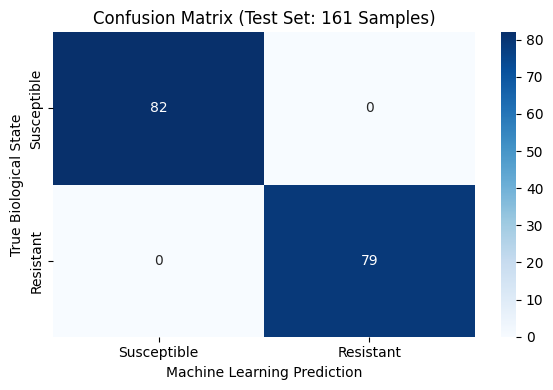

In [6]:
try:
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=["Susceptible", "Resistant"],
        yticklabels=["Susceptible", "Resistant"],
    )
    plt.title(f"Confusion Matrix (Test Set: {len(y_test)} Samples)")
    plt.ylabel("True Biological State")
    plt.xlabel("Machine Learning Prediction")
    plt.tight_layout()

    cm_path = PLOT_DIR / "confusion_matrix.png"
    plt.savefig(cm_path, dpi=150)
    logger.info("Confusion matrix saved to %s", cm_path)
    plt.show()
except Exception:
    logger.exception("Failed while plotting the confusion matrix.")
    raise


### Step 6: ROC Curve *(New Evaluation Plot)*
* Added an ROC curve as an extra evaluation visualization.
* Used the trained SVM's `decision_function()` without changing the model or retraining it.
* Saved the ROC curve (with AUC) to `outputs/plots/roc_curve.png`.


08:03:12 | INFO | ROC curve saved to plant_genome_project/outputs/plots/roc_curve.png (AUC = 1.000)
INFO:plant_genome_pipeline:ROC curve saved to plant_genome_project/outputs/plots/roc_curve.png (AUC = 1.000)


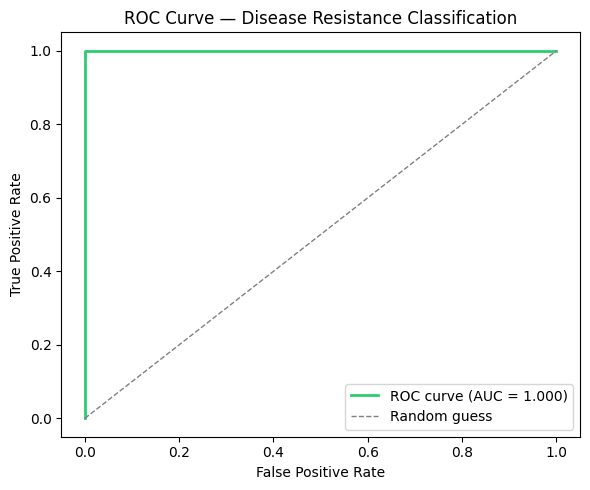

In [7]:
try:
    decision_scores = svm_model.decision_function(X_test_selected)
    fpr, tpr, _ = roc_curve(y_test, decision_scores)
    roc_auc = roc_auc_score(y_test, decision_scores)

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, color="#2ecc71", lw=2, label=f"ROC curve (AUC = {roc_auc:.3f})")
    plt.plot([0, 1], [0, 1], color="gray", lw=1, linestyle="--", label="Random guess")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve \u2014 Disease Resistance Classification")
    plt.legend(loc="lower right")
    plt.tight_layout()

    roc_path = PLOT_DIR / "roc_curve.png"
    plt.savefig(roc_path, dpi=150)
    logger.info("ROC curve saved to %s (AUC = %.3f)", roc_path, roc_auc)
    plt.show()
except Exception:
    logger.exception("Failed while plotting the ROC curve.")
    raise


### Step 7: PCA Visualization of Genomic Clusters
* Added `RANDOM_STATE` to ensure reproducible PCA results.
* Saved the plot to `outputs/plots/pca_clusters.png`.
* Added logging and `try/except` error handling.

08:03:18 | INFO | Running PCA on the selected genes for cluster visualization.
INFO:plant_genome_pipeline:Running PCA on the selected genes for cluster visualization.
08:03:18 | INFO | PC1 explains 63.70% variance; PC2 explains 1.39% variance.
INFO:plant_genome_pipeline:PC1 explains 63.70% variance; PC2 explains 1.39% variance.
08:03:20 | INFO | PCA cluster plot saved to plant_genome_project/outputs/plots/pca_clusters.png
INFO:plant_genome_pipeline:PCA cluster plot saved to plant_genome_project/outputs/plots/pca_clusters.png


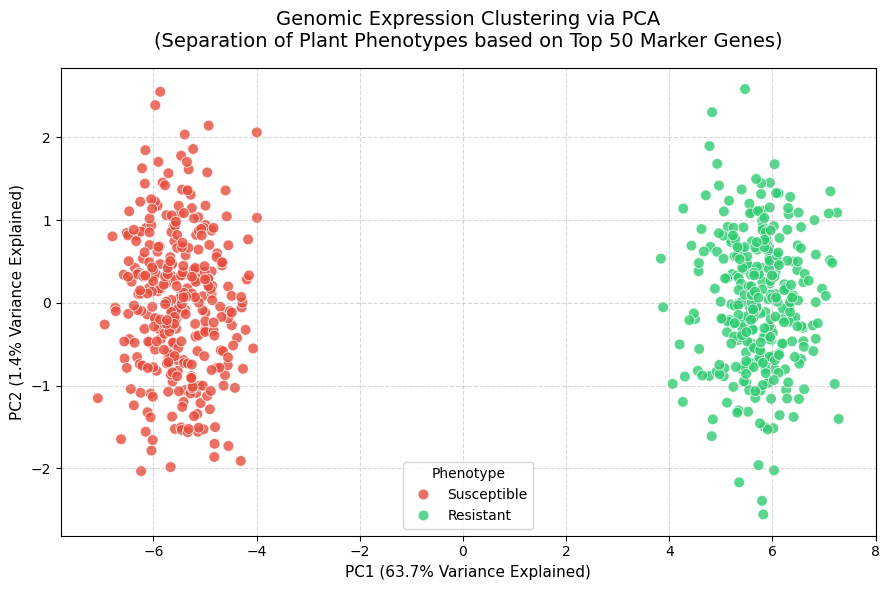

In [8]:
try:
    logger.info("Running PCA on the selected genes for cluster visualization.")
    pca = PCA(n_components=2, random_state=RANDOM_STATE)
    X_train_pca = pca.fit_transform(X_train_selected)
    explained_variance = pca.explained_variance_ratio_ * 100
    logger.info(
        "PC1 explains %.2f%% variance; PC2 explains %.2f%% variance.",
        explained_variance[0], explained_variance[1],
    )

    df_pca = pd.DataFrame(data=X_train_pca, columns=["Principal Component 1", "Principal Component 2"])
    df_pca["Biological State"] = ["Resistant" if label == 1 else "Susceptible" for label in y_train]

    plt.figure(figsize=(9, 6))
    sns.scatterplot(
        x="Principal Component 1",
        y="Principal Component 2",
        hue="Biological State",
        palette=["#e74c3c", "#2ecc71"],  # Red = Susceptible, Green = Resistant
        data=df_pca,
        alpha=0.8,
        edgecolor="w",
        s=60,
    )
    plt.title(
        "Genomic Expression Clustering via PCA\n"
        "(Separation of Plant Phenotypes based on Top 50 Marker Genes)",
        fontsize=14, pad=15,
    )
    plt.xlabel(f"PC1 ({explained_variance[0]:.1f}% Variance Explained)", fontsize=11)
    plt.ylabel(f"PC2 ({explained_variance[1]:.1f}% Variance Explained)", fontsize=11)
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.legend(title="Phenotype", loc="best")
    plt.tight_layout()

    pca_path = PLOT_DIR / "pca_clusters.png"
    plt.savefig(pca_path, dpi=150)
    logger.info("PCA cluster plot saved to %s", pca_path)
    plt.show()
except Exception:
    logger.exception("Failed while running / plotting PCA.")
    raise


## Step 8: Save Trained Artifacts with joblib
- Same three artifacts are saved with `joblib.dump`, unchanged: the trained SVM, the fitted
  `StandardScaler`, and the fitted `SelectKBest` selector.
- Files now go into the dedicated `models/` folder instead of the notebook's working
  directory (per the requested "Folder structure" improvement), and filenames are kept
  identical so any existing loading code still works.
- Mixed-language comments from the original ("kyunki...zaroori hai", "taake...hain") were
  rewritten in plain English for clarity/professionalism.
- Wrapped in `try/except` with logging.

In [9]:
try:
    model_path = MODEL_DIR / "plant_disease_svm_model.pkl"
    scaler_path = MODEL_DIR / "genomic_scaler.pkl"
    selector_path = MODEL_DIR / "gene_selector.pkl"

    # Save the trained SVM model
    joblib.dump(svm_model, model_path)
    # Save the scaler (new data must be normalized the same way before prediction)
    joblib.dump(scaler, scaler_path)
    # Save the feature selector (so inference uses the exact same 50 genes)
    joblib.dump(selector, selector_path)

    logger.info("Model, scaler, and selector saved successfully.")
    logger.info("Files: %s, %s, %s", model_path, scaler_path, selector_path)
except Exception:
    logger.exception("Failed while saving model artifacts with joblib.")
    raise


08:03:29 | INFO | Model, scaler, and selector saved successfully.
INFO:plant_genome_pipeline:Model, scaler, and selector saved successfully.
08:03:29 | INFO | Files: plant_genome_project/models/plant_disease_svm_model.pkl, plant_genome_project/models/genomic_scaler.pkl, plant_genome_project/models/gene_selector.pkl
INFO:plant_genome_pipeline:Files: plant_genome_project/models/plant_disease_svm_model.pkl, plant_genome_project/models/genomic_scaler.pkl, plant_genome_project/models/gene_selector.pkl


## Step 9: Load Artifacts & Inference Template
- Same loading calls (`joblib.load`) for the model, scaler, and selector, and the same
  commented-out inference template showing how to score new data.
- Paths now point to the `models/` folder created in Step 0.
- Wrapped in `try/except` with logging so a missing/corrupted artifact file is reported
  clearly instead of raising a raw traceback.

In [10]:
try:
    loaded_model = joblib.load(model_path)
    loaded_scaler = joblib.load(scaler_path)
    loaded_selector = joblib.load(selector_path)
    logger.info("Model, scaler, and selector loaded successfully for inference.")

    # Example inference workflow for new genomic data:
    # X_new_scaled   = loaded_scaler.transform(new_plant_data)
    # X_new_selected = loaded_selector.transform(X_new_scaled)
    # predictions    = loaded_model.predict(X_new_selected)
except Exception:
    logger.exception("Failed while loading saved artifacts.")
    raise


08:03:33 | INFO | Model, scaler, and selector loaded successfully for inference.
INFO:plant_genome_pipeline:Model, scaler, and selector loaded successfully for inference.
